In this notebook I do a similar analysis as the simulations just to real data (still evaluating the ability of the metrics to predict some parcellation evaluation metric in this case cos error). I used a frontal cortex ROI I made up. MDTB-s1 was used for training and predicition error was done using MDTB-s2 and only within voxels in the ROI used. Here since we are looking at predicition error, for evaluation of metric lower is better (e.g., the higher the log_det the lower the predicition error)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import OptimalBattery.util as ut
from Functional_Fusion.dataset import DataSetMDTB
import os
import pickle
import Functional_Fusion.atlas_map as am
from IndividualParcellation.global_config import *
import OptimalBattery.evaluate as ev
import PcmPy as pcm
import seaborn as sns
import nilearn.plotting as plotting
import nitools as nt
import pandas as pd


Default device set to: cuda


# define atlas for data used and ROI mask dir

In [2]:
space = 'SUIT3'
atlas,_= am.get_atlas(atlas_str=space)
base_dir = 'Y:/data/FunctionalFusion/'
if not os.path.exists(base_dir):
    base_dir = '/cifs/diedrichsen/data/FunctionalFusion/'
cort_dir = 'Y:/data/Atlas_templates/fs_LR_32'

# Get Vs for mdtb_1 and mdtb_2 from nettekoven 32

In [50]:
model_dir = 'Y:/data/Cerebellum/ProbabilisticParcellationModel/Models/Models_03/NettekovenSym32_space-MNISymC2_D5.pickle'
with open(model_dir, 'rb') as f:
    full_model = pickle.load(f)[0]

# load emission model & Vs for mdtb ses-1
mdtb_1_emission = full_model.emissions[0]
mdtb_1_Vs = mdtb_1_emission.V
VL_mdtb_1 = mdtb_1_Vs.cpu().numpy()
VL_mdtb_1 = VL_mdtb_1[:28,:]

mdtb_2_emission = full_model.emissions[1]
mdtb_2_Vs = mdtb_2_emission.V
VL_mdtb_2 = mdtb_2_Vs.cpu().numpy()


# Load data

In [42]:
MDTB_dataset = DataSetMDTB('/cifs/diedrichsen/data/FunctionalFusion/MDTB')
if not os.path.exists('/cifs/diedrichsen/data/FunctionalFusion/MDTB'):
    MDTB_dataset = DataSetMDTB('Y:/data/FunctionalFusion/MDTB')

data_mdtb_s1_run,info_mdtb_1_run  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondRun')
data_mdtb_s1_run[np.isnan(data_mdtb_s1_run)] = 0
data_mdtb_s1_run = data_mdtb_s1_run[:,:,:]



data_mdtb_s1_all,info_mdtb_1_all  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondAll')
data_mdtb_s1_all[np.isnan(data_mdtb_s1_all)] = 0
data_mdtb_s1_all = data_mdtb_s1_all[:,:,:]




data_mdtb_s2_all,info_mdtb_2_all  =MDTB_dataset.get_data(space=space,ses_id='ses-s2',type='CondAll')
data_mdtb_s2_all[np.isnan(data_mdtb_s2_all)] = 0


In [43]:
def process_subject_run_preserve_shape(data, info):

    n_subjects, n_conditions, n_voxels = data.shape
    n_runs = info['run'].nunique()
    conditions_per_run = n_conditions // n_runs  # Assuming equal conditions per run

    # The fixed index for 'rest' (29th condition, 0-based index is 28)
    rest_idx = 28

    # Prepare storage for processed data
    processed_data = np.zeros((n_subjects, n_conditions - n_runs, n_voxels))
    updated_info = []

    # Loop over each subject
    for subject_idx in range(n_subjects):
        subject_data = data[subject_idx]  # (conditions, voxels)
        subject_info = info.copy()

        subject_processed_data = []
        
        # Process each run for the current subject
        for run in subject_info['run'].unique():
            run_mask = subject_info['run'] == run
            run_data = subject_data[run_mask]  # Extract data for this run
            run_info = subject_info[run_mask]  # Extract info for this run

            # Extract 'rest' condition and subtract it from the run
            rest_data = run_data[rest_idx]  # Extract 'rest' condition data
            adjusted_run_data = np.delete(run_data, rest_idx, axis=0) - rest_data

            # Remove 'rest' condition from the run's metadata
            adjusted_run_info = run_info.drop(index=run_info.index[rest_idx])

            # Append processed run data and updated info
            subject_processed_data.append(adjusted_run_data)
            updated_info.append(adjusted_run_info)

        # Combine processed runs for the subject
        processed_data[subject_idx] = np.vstack(subject_processed_data)

    # Combine info across all subjects and runs
    updated_info = pd.concat(updated_info, ignore_index=True)

    return processed_data, updated_info

data_mdtb_s1_run, info_mdtb_1_run = process_subject_run_preserve_shape(data_mdtb_s1_run, info_mdtb_1_run)
print(data_mdtb_s1_run.shape)

(24, 448, 6918)


In [44]:
# find rest index in info file
rest_index = np.where(info_mdtb_1_all['cond_name']=='rest')[0]

# subtract rest from all the data
data_mdtb_s1_rest = data_mdtb_s1_all[:,rest_index,:]

data_mdtb_s1_all = data_mdtb_s1_all - data_mdtb_s1_rest
data_mdtb_s1_all = data_mdtb_s1_all[:,:28,:]
print(data_mdtb_s1_all.shape)

(24, 28, 6918)


In [45]:
# make a data of shape 1 x data_mdtb_s1_all.shape[2] of 1s
ROI_mask = np.ones((data_mdtb_s1_all.shape[2]),)
ROI_indices = np.where(ROI_mask == 1)[0]



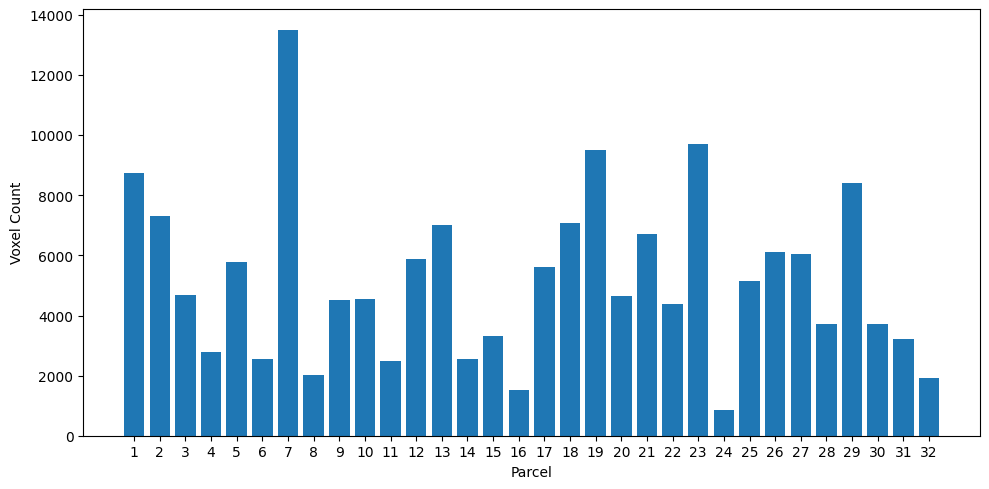

In [46]:
# make random noise data (baseline), project voxels to parcels and count voxel per parcel
data_mdtb_s1_all_noise = np.random.rand(data_mdtb_s1_all.shape[0],data_mdtb_s1_all.shape[1],data_mdtb_s1_all.shape[2])
total_parcel_counts = np.zeros(32)

for subject_data in data_mdtb_s1_all_noise:
    data = subject_data[:, ROI_indices]
    
    data_projected = VL_mdtb_1.T @ data
    data_projected_onehot = ev.get_U_hat_one_hot(data_projected)[0]
    
    total_parcel_counts += np.sum(data_projected_onehot, axis=1)

plt.figure(figsize=(10, 5))
plt.bar(range(1, 33), total_parcel_counts, tick_label=range(1, 33))
plt.xlabel('Parcel')
plt.ylabel('Voxel Count')
plt.tight_layout()
plt.show()

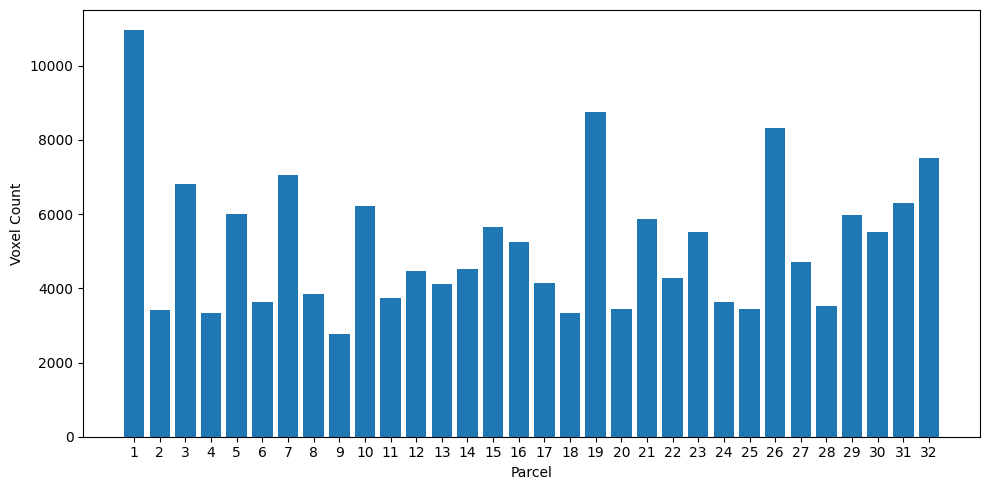

array([ 0, 18, 25, 31,  6,  2, 30,  9], dtype=int64)

In [66]:
# get top 4 parcels with highest voxel counts within ROI
total_parcel_counts = np.zeros(32)

for subject_data in data_mdtb_s1_all:
    data = subject_data[:, ROI_indices]
    
    data_projected = VL_mdtb_1.T @ data
    data_projected_onehot = ev.get_U_hat_one_hot(data_projected)[0]
    
    total_parcel_counts += np.sum(data_projected_onehot, axis=1)

plt.figure(figsize=(10, 5))
plt.bar(range(1, 33), total_parcel_counts, tick_label=range(1, 33))
plt.xlabel('Parcel')
plt.ylabel('Voxel Count')
plt.tight_layout()
plt.show()

# choose 4 parcels with top voxel counts
top_parcels = np.argsort(total_parcel_counts)[::-1][:8]
top_parcels



pretty reasonable S and D region Vs seem to capture the biggest amount of voxels in the frontal cortex ROI

# subset VLib and Vtest to only include parcels with most voxels in ROI

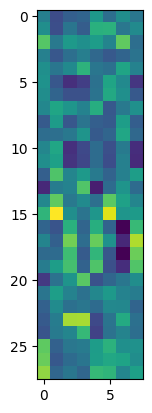

In [67]:
VLib = VL_mdtb_1[:,top_parcels]
plt.imshow(VLib)

In [68]:
vtest =  VL_mdtb_2[:,top_parcels]
vtest.shape

(32, 8)

# Get crossvalidated second moment matrix (GLib)

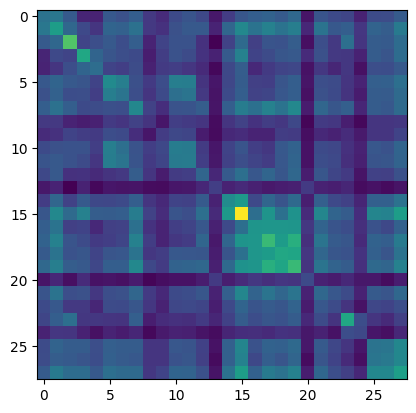

In [69]:
cond_vec = np.tile(np.arange(1, 28 + 1), 16)
part_vec = np.repeat(np.arange(1, 16 + 1), 28)
Gs_list = []
E_list = []
for i in range(data_mdtb_s1_run.shape[0]):
    Gs,E = pcm.util.est_G_crossval(data_mdtb_s1_run[i][:,ROI_indices] , cond_vec, part_vec)
    Gs_list.append(Gs)
    E_list.append(E)

Gs_list = np.stack(Gs_list, 0)
G_Lib = np.mean(Gs_list, axis=0)

plt.imshow(G_Lib)

In [97]:
D = ut.build_combinations(G_Lib, strategy='random',n_iter=2500,n_tasks=4,seed=1,replacement=True)
D_ev = ev.evaluate_dataframe_real_multiregion(D, data_mdtb_s1_all,VLib,data_mdtb_s2_all, vtest,ROI_indices)


Processing combination: 0
Processing combination: 10
Processing combination: 20
Processing combination: 30
Processing combination: 40
Processing combination: 50
Processing combination: 60
Processing combination: 70
Processing combination: 80
Processing combination: 90
Processing combination: 100
Processing combination: 110
Processing combination: 120
Processing combination: 130
Processing combination: 140
Processing combination: 150
Processing combination: 160
Processing combination: 170
Processing combination: 180
Processing combination: 190
Processing combination: 200
Processing combination: 210
Processing combination: 220
Processing combination: 230
Processing combination: 240
Processing combination: 250
Processing combination: 260
Processing combination: 270
Processing combination: 280
Processing combination: 290
Processing combination: 300
Processing combination: 310
Processing combination: 320
Processing combination: 330
Processing combination: 340
Processing combination: 350
Pro

In [89]:
# save dataframe in current repo dataframes folder
save_path = os.path.join(os.getcwd(), '..', 'dataframes')
# D_ev.to_csv(os.path.join(save_path, 'cerebellum_MDTB_s1_s2_top8parcels_8tasks.tsv'), sep='\t', index=False)
# load
# D_ev = pd.read_csv(os.path.join(save_path, 'cerebellum_MDTB_s1_s2_top8parcels_8tasks.tsv'), sep='\t')
D_sub= D_ev

In [90]:
# D_sub = D_ev[D_ev['n_unique'] == 6]
len(D_sub)

2400

(-10000.0, -100.0)

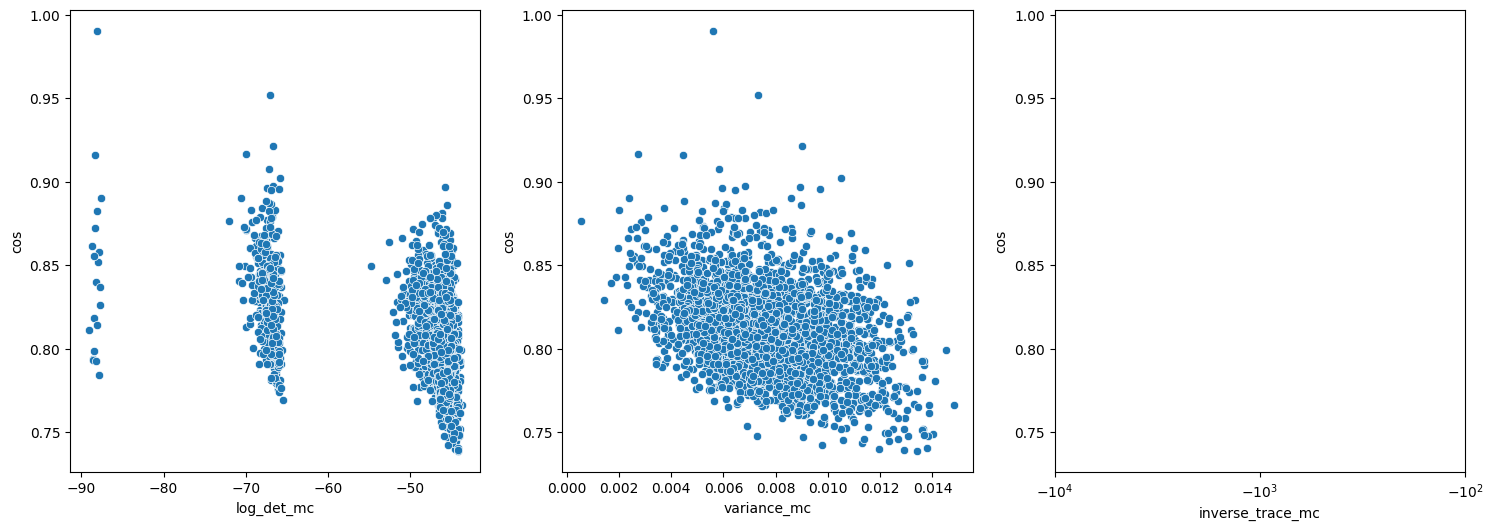

In [91]:

fig, ax = plt.subplots(1, 3, figsize=(18, 6))
sns.scatterplot(data=D_sub, x='log_det_mc', y='cos', ax=ax[0])
sns.scatterplot(data=D_sub, x='variance_mc', y='cos', ax=ax[1])
sns.scatterplot(data=D_sub, x='inverse_trace_mc', y='cos', ax=ax[2])
ax[2].set_xscale('symlog', linthresh=1)
ax[2].set_xlim(-10000, -100)

In [92]:
D_sub['n_unique'].value_counts()


n_unique
4    1903
3     477
2      20
Name: count, dtype: int64

In [93]:
sample_sizes = range(10, len(D_sub)+1, 10) 
metrics = ['log_det_mc', 'variance','variance_mc', 'inverse_trace_mc']

correlation_data = []
for n in sample_sizes:
    # give updates
    if n % 1000 == 0:
        print(f'Processing sample size {n}')
    for metric in metrics:
        top_n = D_sub.nlargest(n, metric)
        # find mean of cos values for top n\
        mean_cos = top_n['cos'].mean()        
        correlation_data.append({
            'Sample Size': n,
            'Metric': metric,
            'mean_cos': mean_cos,
        })

correlation_df = pd.DataFrame(correlation_data)




Processing sample size 1000
Processing sample size 2000


(array([ 19.,  44., 172., 264., 388., 419., 424., 329., 174.,  86.,  46.,
         21.,   8.,   1.,   3.,   0.,   1.,   0.,   0.,   1.]),
 array([0.73888651, 0.75146261, 0.7640387 , 0.77661479, 0.78919089,
        0.80176698, 0.81434307, 0.82691917, 0.83949526, 0.85207135,
        0.86464745, 0.87722354, 0.88979963, 0.90237572, 0.91495182,
        0.92752791, 0.940104  , 0.9526801 , 0.96525619, 0.97783228,
        0.99040838]),
 <BarContainer object of 20 artists>)

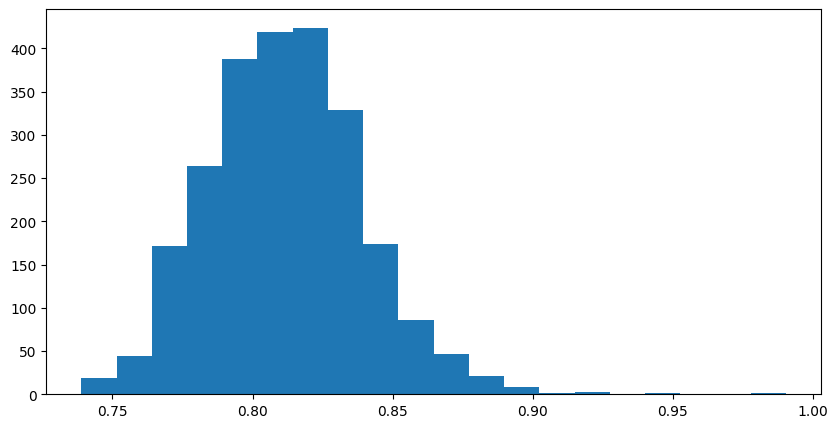

In [94]:
# plot cos values in D_sub
plt.figure(figsize=(10, 5))
plt.hist(D_sub['cos'], bins=20)

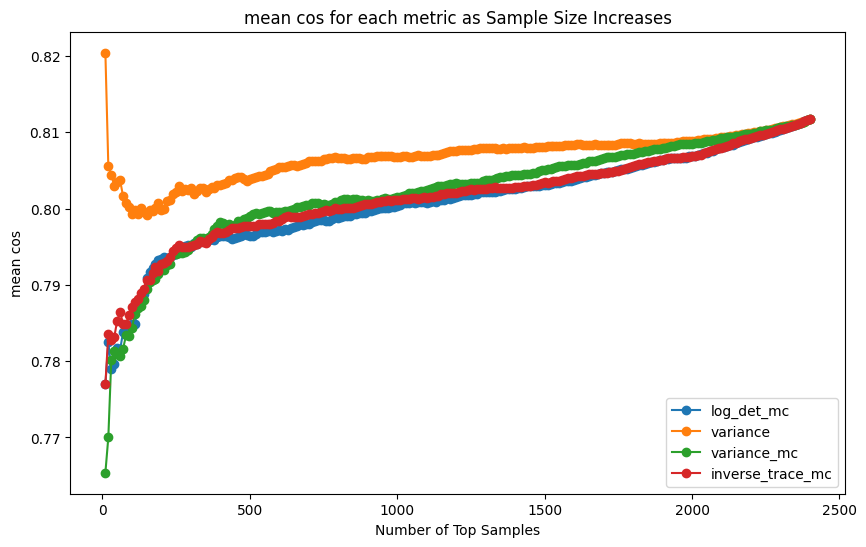

In [95]:
# Plotting Spearman
plt.figure(figsize=(10, 6))
for metric in metrics:
    subset = correlation_df[correlation_df['Metric'] == metric]
    plt.plot(subset['Sample Size'], subset['mean_cos'], label=metric, marker='o')
plt.title('mean cos for each metric as Sample Size Increases')
plt.xlabel('Number of Top Samples')
plt.ylabel('mean cos')
plt.legend()
plt.show()